# 2.3.2 平衡位置与靠近速度

## 学习目标与先修知识

能分开解释平衡（equilibrium）位置和时间尺度（time scale），用自然对数（natural logarithm）求首次达到指定比例的时刻，辨认零清除与平衡初值（initial condition）等特例。

先修：上一节的恒定输入（input）解，指数和对数互逆。 [复习上一节](01-从收支率到一阶初值问题.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

两个系统最终都接近 2 U，它们是否一样快？若让流入和清除系数（elimination rate constant）一起加倍，保持了什么，又改变了什么？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
for k in [.5,1]:
    u=2*k
    values=[2*(1-math.exp(-k*t)) for t in [0,1,2,4]]
    display(Markdown(show_table([f'k={k} /T; t / T','A / U'],zip([0,1,2,4],values))))

| k=0.5 /T; t / T | A / U |
| --- | --- |
| 0 | 0 |
| 1 | 0.786939 |
| 2 | 1.26424 |
| 4 | 1.72933 |

| k=1 /T; t / T | A / U |
| --- | --- |
| 0 | 0 |
| 1 | 1.26424 |
| 2 | 1.72933 |
| 4 | 1.96337 |

## 模型假设

仍采用恒定输入理想单室模型（one-compartment model）。先固定 A0=0、u>0、k>0；比较时保持目标平衡 A*=2 U，通过 u=kA* 联动。这样可以比较平衡位置相同、接近速度不同的过程。

## 数学解释与推导

在 $k>0$ 时，偏离平衡的幅度满足 $|A(t)-A^*|=|A_0-A^*|e^{-kt}$。非零初始偏离可归一化为
$$\frac{A(t)-A^*}{A_0-A^*}=e^{-kt}\quad(A_0\ne A^*).$$
使指数等于 −1 的时刻定义为特征时间（characteristic time） $\tau=1/k$，单位 T。过一个 τ 后还剩原偏离的 $e^{-1}\approx36.8\%$；若从零出发，则达到平衡量的 $1-e^{-1}\approx63.2\%$。这不是偏离幅度减半的时刻。

求非零偏离幅度减半：$e^{-kt}=1/2$，取自然对数，得偏离平衡的**半衰时间（deviation half-time）**
$$t_{1/2,\mathrm{dev}}=\frac{\ln2}{k}.$$
当 $u=0$ 时，$A^*=0$，它才同时是非零所追踪物质总量（tracked amount） $A$ 的通常半衰期（half-life）。本节从 $A_0=0$、$u>0$ 出发时，$A(t)$ 在增加；减半的是距平衡的幅度，并非 $A$ 自身。若 $A_0=A^*$，偏离始终为零，不存在可观察的非零偏离减半过程。

从零达到平衡比例 f 时，$1-e^{-kt}=f$，因此
$$t_f=-\frac{\ln(1-f)}k,\qquad0\le f<1.$$
f=0 对应起点；f=1 没有有限到达时刻。u 已在比例中抵消，但它仍决定绝对总量。代码用 `log1p(-f)` 准确计算接近零的 $\ln(1-f)$。

把 u、k 同时加倍，u/k 不变，τ 减半。若初值就在平衡，整条曲线都不变，不能从它辨认靠近速度。k=0 时没有这里的有限时间尺度；不能把 1/k 直接用于该分支。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def exact_amount(time, u, k, A0):
    import math
    if k == 0:
        return A0 + u * time
    # expm1(z)/z tends to 1; this avoids both cancellation and a huge u/k.
    z = -k * time
    ratio = 1.0 if z == 0 else math.expm1(z) / z
    return A0 * math.exp(z) + u * time * ratio

def exact_series(A0, u, k, times):
    return [exact_amount(t, u, k, A0) for t in times]

def fraction_times(k, fractions):
    import math
    return [-math.log1p(-f) / k for f in fractions]

## 对照实验

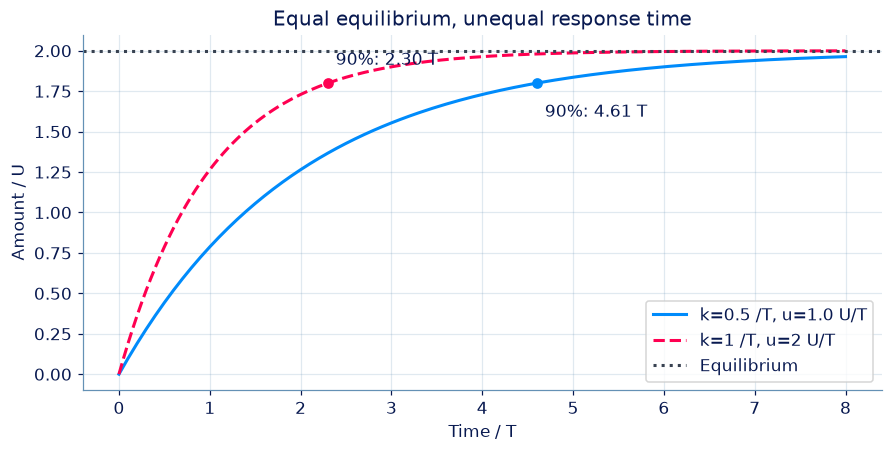

| k / (1/T) | tau / T | 偏离半衰时间 / T | 达到90% / T |
| --- | --- | --- | --- |
| 0.5 | 2 | 1.38629 | 4.60517 |
| 1 | 1 | 0.693147 | 2.30259 |

In [4]:
times=np.linspace(0,8,161)
fig,ax=plt.subplots()
for k,style,color in [(.5,'-','#008bfb'),(1,'--','#ff0051')]:
    ax.plot(times,exact_series(0,2*k,k,times),style,color=color,label=f'k={k} /T, u={2*k} U/T')
    t90=fraction_times(k,[.9])[0]
    ax.plot([t90],[1.8],'o',color=color);ax.annotate(f'90%: {t90:.2f} T',(t90,1.8),xytext=(5,-22 if k==.5 else 12),textcoords='offset points')
ax.axhline(2,color='#384251',ls=':',label='Equilibrium')
ax.set(xlabel='Time / T',ylabel='Amount / U',title='Equal equilibrium, unequal response time');ax.legend(loc='lower right');plt.show()
display(Markdown(show_table(['k / (1/T)','tau / T','偏离半衰时间 / T','达到90% / T'],[(k,1/k,math.log(2)/k,fraction_times(k,[.9])[0]) for k in [.5,1]])))

## 结果解释

两条曲线终点趋势相同，但 k=1/T 的系统在约 2.303 T 达到 90%，k=0.5/T 的系统需约 4.605 T。偏离半衰时间、特征时间和从零达到平衡量 90% 的时间是三个不同量，必须连同定义一起使用。

### 独立核对

由时间公式算出的结果再代回原总量解，而不是用同一个对数表达式比较自身。

In [5]:
for k in [.1,.5,1]:
    fractions=[0,.5,.9,.99]
    reached=fraction_times(k,fractions)
    np.testing.assert_allclose([exact_amount(t,2*k,k,0)/2 for t in reached],fractions,atol=1e-12)
    assert math.isclose(math.exp(-k*(math.log(2)/k)),.5)
np.testing.assert_allclose(fraction_times(1,[.5,.9]),np.array(fraction_times(.5,[.5,.9]))/2)
for initial in [0, 1, 3]:
    # Above and below equilibrium, the absolute deviation halves.
    at_half = exact_amount(math.log(2)/.5, 1, .5, initial)
    assert math.isclose(abs(at_half-2), abs(initial-2)/2)
assert exact_amount(2, 1, .5, 2) == 2
assert math.isclose(exact_amount(math.log(2)/.5, 0, .5, 3), 1.5)
print('回代比例、偏离半衰时间、无输入半衰期及平衡初值均一致。')

回代比例、偏离半衰时间、无输入半衰期及平衡初值均一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/02-03-连续时间与一阶微分方程/explore/)：先预测改变一个条件后的结果，再回到这里对照推导与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 多项选择题：同一平衡，不同速度

将恒定输入（input）模型（model）中的 u>0 和 k>0 同时乘 2，初值（initial condition）保持不变。哪些结论正确？

- **A.** 平衡（equilibrium）量 u/k 不变。
- **B.** 特征时间（characteristic time） 1/k 减半。
- **C.** 每个相同时刻的所追踪物质总量（tracked amount）必然与原来相同。
- **D.** 同样的偏离衰减比例在一半时间内达到。

[作答：同一平衡，不同速度](http://127.0.0.1:8000/chapters/02-03-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E4%B8%8E%E4%B8%80%E9%98%B6%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p02-timescale)

### 第 2 题 · Python 计算题：到达指定平衡比例要多久

从 A0=0 出发，u>0、k>0。解为 A(t)=(u/k)(1−exp(−kt))。给定若干比例 f，返回首次达到 f×(u/k) 的时刻。

**函数与代码模板**

```python
def solve(
    k: float,
    fractions: list[float],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `k` | `float` | 清除系数（elimination rate constant）。 | 1/T |
| `fractions` | `list[float]` | 目标平衡（equilibrium）比例 f。 | 1 |

**返回值**

直接返回 times（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 与目标比例一一对应的首次达到时刻。 | T |

**计算规则**

由 exp(−kt)=1−f 得到 t=−log(1−f)/k，可用 math.log1p(−f)。f=0 返回 0；不包含永远无法有限时间精确达到的 f=1。

**约束与边界**

- 所有数值有限；无需修改输入（input）。
- 1e−4 ≤ k ≤ 2；0 ≤ f ≤ 0.999999；列表长度 0—100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| k | 清除系数（elimination rate constant）。 | 0.5 | 1/T |
| fractions | 目标平衡（equilibrium）比例 f。 | [0, 0.5, 0.9] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
k = 0.5
fractions = [0, 0.5, 0.9]

result = solve(k, fractions)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| times | 与目标比例一一对应的首次达到时刻。 | [-0.0, 1.3862943611198906, 4.605170185988092] | T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [-0.0,
                   1.3862943611198906,
                   4.605170185988092]
```

**样例解释**

对应时间为 0、2 ln2≈1.3862943611 T、2 ln10≈4.6051701860 T。u 只决定平衡量，已在比例关系中抵消。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：到达指定平衡比例要多久](http://127.0.0.1:8000/chapters/02-03-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E4%B8%8E%E4%B8%80%E9%98%B6%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p02-arrival)

### 第 3 题 · 单项选择题：一个特征时间之后

无输入（input）衰减 A(t)=A0 exp(−kt)，k>0、A0>0。经过 τ=1/k 后还剩多少初始所追踪物质总量（tracked amount）？

- **A.** 零。
- **B.** 一半。
- **C.** exp(−1)≈36.8%。
- **D.** 63.2%。

[作答：一个特征时间之后](http://127.0.0.1:8000/chapters/02-03-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E4%B8%8E%E4%B8%80%E9%98%B6%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p02-time-constant)

### 第 4 题 · 多项选择题：怎样核验一条候选解

候选函数画得很平滑，且最后靠近平衡（equilibrium）。要检查它是否为给定初值问题（initial value problem）的解析解（analytical solution），还应该做哪些事情？

- **A.** 代入起始时刻，核对初值（initial condition）。
- **B.** 求导并检查每个适用时刻都满足方程。
- **C.** 只检查终点是否接近 u/k。
- **D.** 检查 k=0 等公式分支和变量单位。

[作答：怎样核验一条候选解](http://127.0.0.1:8000/chapters/02-03-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E4%B8%8E%E4%B8%80%E9%98%B6%E5%BE%AE%E5%88%86%E6%96%B9%E7%A8%8B/practice/?question=p02-solution-check)

**进一步阅读**

[MIT 一阶微分方程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-i-first-order-differential-equations/)：指数响应；[Python 对数函数](https://docs.python.org/3/library/math.html#math.log1p)：近零计算。